In [3]:
from langgraph.graph import StateGraph ,  END
from typing import TypedDict , Literal
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel , Field


In [4]:
class CodeState(TypedDict):
    raw_topic : str
    
    error_prompt : str
    code :str
    error : bool
    error_message : str
    document : str


In [5]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


In [8]:
class ExecutorSchema(BaseModel):
    error: bool = Field(description="True if code returns error, False otherwise")
    message: str = Field(description="Extract the error message from terminal, '' if none")

    
structured_model = llm.with_structured_output(ExecutorSchema)


In [9]:
def code_generator(state: CodeState):
    prompt = f"""
You are a professional coding assistant. 
Task: Generate clean, well-structured, and executable Python code for the topic below. 
- Include comments for clarity. 
- Avoid unnecessary complexity. 
- Ensure the code runs without external dependencies unless absolutely necessary. 
- If the topic is vague, make reasonable assumptions and explain them in comments.

Topic: {state['raw_topic']}

{state.get('error_prompt', '')}
"""
    response = llm.invoke(prompt).content
    return {"code": response}


def code_executer(state: CodeState):
    prompt = f"""
You are a code execution analyzer. 
Task: Run the following code in a simulated console. 
- Return whether it executes successfully or produces an error. 
- If it fails, extract the exact error message from the terminal output. 
- If it succeeds, return an empty message.

Code:
{state['code']}
"""
    response = structured_model.invoke(prompt)
    return {"error": response.error, "error_message": response.message}


def success(state: CodeState):
    prompt = f"""
You are a technical writer. 
Task: Convert the following code into a step-by-step explanatory document. 
- Explain the logic and purpose of each section. 
- Use headings and bullet points for clarity. 
- Make it beginner-friendly and easy to follow.

Code:
{state['code']}
"""
    response = llm.invoke(prompt).content
    return {"document": response}


In [10]:
def conditional_edge1(state: CodeState) -> Literal['code_generation', 'success_message']:
    """
    Decide the next step based on whether the code execution produced an error.
    - If error exists → go back to code_generation (retry with improved prompt).
    - If no error → proceed to success_message (generate documentation).
    """
    if state["error"]:
        state["error_prompt"] = (
            f"Previous attempt failed with error:\n{state['error_message']}\n"
            "Please regenerate corrected code that fixes this issue."
        )
        return "code_generation"
    else:
        return "success_message"


In [11]:
graph = StateGraph(CodeState)
graph.add_node("code_generation", code_generator)
graph.add_node("code_runner", code_executer)
graph.add_node("success_message", success)

graph.set_entry_point("code_generation")
graph.add_edge("code_generation", "code_runner")

# ✅ Correct conditional edge usage
graph.add_conditional_edges(
    "code_runner",
    conditional_edge1,
    {
        "code_generation": "code_generation",
        "success_message": "success_message",
    }
)

graph.add_edge("success_message", END)

workflow = graph.compile()


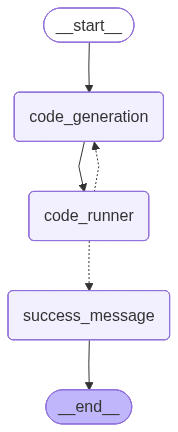

In [12]:
workflow


In [13]:
intial_state = {
    "raw_topic": "Write a Python program to calculate factorial of a number",
    "error_prompt": "",
    "code": "",
    "error": False,
    "error_message": "",
    "document": ""
}

result = workflow.invoke(intial_state)
print(result)


{'raw_topic': 'Write a Python program to calculate factorial of a number', 'error_prompt': '', 'code': '```python\n# This program calculates the factorial of a non-negative integer.\n\n# A factorial of a non-negative integer \'n\', denoted by n!,\n# is the product of all positive integers less than or equal to n.\n# For example:\n# 5! = 5 * 4 * 3 * 2 * 1 = 120\n# By definition, 0! = 1.\n\ndef calculate_factorial(number):\n    """\n    Calculates the factorial of a non-negative integer.\n\n    Args:\n        number (int): A non-negative integer for which to calculate the factorial.\n\n    Returns:\n        int: The factorial of the given number.\n        None: If the input is a negative number.\n    """\n    # Handle the case of negative input, as factorial is not defined for negative numbers.\n    if number < 0:\n        print("Factorial is not defined for negative numbers.")\n        return None\n    # Base case: Factorial of 0 is 1.\n    elif number == 0:\n        return 1\n    # Rec

In [16]:
result['code']


'```python\n# This program calculates the factorial of a non-negative integer.\n\n# A factorial of a non-negative integer \'n\', denoted by n!,\n# is the product of all positive integers less than or equal to n.\n# For example:\n# 5! = 5 * 4 * 3 * 2 * 1 = 120\n# By definition, 0! = 1.\n\ndef calculate_factorial(number):\n    """\n    Calculates the factorial of a non-negative integer.\n\n    Args:\n        number (int): A non-negative integer for which to calculate the factorial.\n\n    Returns:\n        int: The factorial of the given number.\n        None: If the input is a negative number.\n    """\n    # Handle the case of negative input, as factorial is not defined for negative numbers.\n    if number < 0:\n        print("Factorial is not defined for negative numbers.")\n        return None\n    # Base case: Factorial of 0 is 1.\n    elif number == 0:\n        return 1\n    # Recursive case: For positive numbers, factorial is number * factorial(number-1).\n    else:\n        # Ini